## 📦 1. Importation des bibliothèques nécessaires

Avant de commencer l’analyse des données, nous importons les bibliothèques Python essentielles qui nous serviront à manipuler les données et à créer des visualisations.

In [251]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## 📂 2. Chargement du jeu de données

Dans cette section, nous chargeons les données depuis un fichier CSV local en utilisant la bibliothèque `pandas`.

In [252]:
# Load the dataset
file_path = "avito_data.csv"
df = pd.read_csv(file_path)

## 📝 3. Aperçu initial du jeu de données

Avant de commencer l'analyse exploratoire, il est utile d’avoir un premier aperçu des données : voir les premières lignes, connaître la taille du jeu de données, et les noms des colonnes disponibles.


In [253]:
df.head()
df.shape
df.columns

Index(['Titre', 'Secteur', 'Ville', 'Prix', 'Annee-Modele',
       'Boite de vitesses', 'Type de carburant', 'Kilometrage', 'Marque',
       'Modele', 'Nombre de portes', 'Origine', 'Premiere main',
       'Puissance fiscale', 'Etat'],
      dtype='object')

## 🔍 4. Analyse des valeurs manquantes

Cette section permet de repérer les colonnes contenant des valeurs manquantes et d’évaluer leur impact en calculant le pourcentage de données absentes. Cela nous aide à choisir les bonnes méthodes de traitement, comme l’imputation ou la suppression, pour garantir la qualité de l’analyse à venir.


In [254]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
pd.DataFrame({'Missing Values': missing, 'Percent': missing_percent}).sort_values(by='Percent', ascending=False)

,Missing Values,Percent
Prix,18308,24.617453
Premiere main,12973,17.443862
Origine,11684,15.710636
Nombre de portes,11383,15.305903
Etat,4869,6.546995
Kilometrage,2614,3.514858
Puissance fiscale,2436,3.275514
Boite de vitesses,2180,2.931289
Marque,1886,2.535969
Modele,1886,2.535969


## 🧼 5. Création d’une copie pour le nettoyage

Avant de modifier les données, il est important de créer une copie du DataFrame original. Cela permet de conserver les données brutes intactes pour référence ou comparaison. On affiche ensuite les informations générales du DataFrame (types de données, valeurs non nulles) afin d’évaluer les transformations nécessaires.


In [255]:
# Make a copy to clean
df_eda = df.copy()
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74370 entries, 0 to 74369
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Titre              74370 non-null  object 
 1   Secteur            74259 non-null  object 
 2   Ville              74259 non-null  object 
 3   Prix               56062 non-null  float64
 4   Annee-Modele       72517 non-null  object 
 5   Boite de vitesses  72190 non-null  object 
 6   Type de carburant  72559 non-null  object 
 7   Kilometrage        71756 non-null  float64
 8   Marque             72484 non-null  object 
 9   Modele             72484 non-null  object 
 10  Nombre de portes   62987 non-null  float64
 11  Origine            62686 non-null  object 
 12  Premiere main      61397 non-null  object 
 13  Puissance fiscale  71934 non-null  float64
 14  Etat               69501 non-null  object 
dtypes: float64(4), object(11)
memory usage: 8.5+ MB


## 🧹 6. Suppression des doublons et des valeurs manquantes

Dans cette étape, nous nous concentrons sur le nettoyage des données en éliminant les doublons afin de garantir que chaque observation soit unique. Cela permet d'éviter d'éventuels biais lors de l'analyse. Nous supprimons également les colonnes non pertinentes, telles que 'Titre', qui ne contribuent pas à l'analyse exploratoire des données (EDA). De plus, les lignes avec des valeurs manquantes dans des colonnes critiques, telles que 'Prix', 'Année-Modèle', 'Puissance fiscale', 'Kilométrage', 'Marque' et 'Modèle', sont supprimées afin de travailler avec des données complètes pour une analyse fiable. Enfin, nous vérifions la forme du jeu de données et les valeurs manquantes restantes pour nous assurer que les données sont prêtes pour l'exploration suivante.


In [256]:
df_eda.duplicated().sum()
df_eda = df_eda.drop_duplicates()

# Drop obviously irrelevant columns for EDA
df_eda.drop(columns=['Titre'], inplace=True)

# Drop rows with missing critical values
df_eda.dropna(subset=['Prix', 'Annee-Modele', 'Puissance fiscale', 'Kilometrage', 'Marque', 'Modele', 'Ville', 'Secteur'], inplace=True)

print(f"Shape after dropping missing values: {df_eda.shape}")
print(df_eda.isnull().sum())

Shape after dropping missing values: (51859, 14)
Secteur                37
Ville                  37
Prix                    0
Annee-Modele            0
Boite de vitesses      96
Type de carburant       0
Kilometrage             0
Marque                  0
Modele                  0
Nombre de portes     5650
Origine              6264
Premiere main        6807
Puissance fiscale       0
Etat                 1789
dtype: int64


## 🧹 7. Conversion des types de données et création de nouvelles variables

Dans cette étape, nous nous concentrons sur la conversion des données en types appropriés pour l’analyse. Les colonnes telles que 'Secteur', 'Ville' et 'Boite de vitesses' sont converties en types catégoriels, ce qui permet de mieux gérer la mémoire et de traiter les données catégorielles de manière plus efficace. Les colonnes numériques comme 'Kilométrage' et 'Annee-Modele' sont converties en types entiers, en s’assurant que les valeurs manquantes sont correctement traitées. De plus, nous traitons les données catégorielles comme 'Premiere main' en les convertissant en type booléen (en mappant "Oui" à 0 et "Non" à 1).

Nous créons ensuite de nouvelles variables comme 'Prix (en milliers MAD)' et 'Kilometrage (en milliers km)' en réduisant les colonnes 'Prix' et 'Kilométrage' à une unité plus maniable. Nous calculons également l'‘Âge’ de la voiture en soustrayant l'‘Annee-Modele’ de l’année actuelle.

Enfin, nous traitons les catégories rares dans les colonnes 'Modele' et 'Marque' en définissant un seuil (50 dans ce cas). Toutes les catégories inférieures à ce seuil sont remplacées par l’étiquette 'Others' afin d’éviter les problèmes liés à un trop grand nombre de catégories uniques dans le jeu de données.


In [257]:
# -----------------------------
# CLEANING FOR EDA
# -----------------------------

# Secteur → category
df_eda['Secteur'] = df_eda['Secteur'].astype('category')

# Ville → category
df_eda['Ville'] = df_eda['Ville'].astype('category')

# Price → float (already float64, just keep)
# Missing values can stay as NaN

# Année-Modèle → integer
df_eda['Annee-Modele'] = pd.to_numeric(df_eda['Annee-Modele'], errors='coerce').astype('Int64')

# Boite de vitesses → category
df_eda['Boite de vitesses'] = df_eda['Boite de vitesses'].astype('category')

# Type de carburant → category
df_eda['Type de carburant'] = df_eda['Type de carburant'].astype('category')

# Kilométrage → integer
df_eda['Kilometrage'] = df_eda['Kilometrage'].astype('Int64')

# Marque → category
df_eda['Marque'] = df_eda['Marque'].astype('category')

# Modèle → category
df_eda['Modele'] = df_eda['Modele'].astype('category')

# Nombre de portes → integer
df_eda['Nombre de portes'] = df_eda['Nombre de portes'].astype('Int64')

# Origine → category
df_eda['Origine'] = df_eda['Origine'].astype('category')

# Première main → boolean (convert from "Oui"/"Non")
df_eda['Premiere main'] = df_eda['Premiere main'].map({'Oui': 0, 'Non': 1}).astype('boolean')

# Puissance fiscale → float (already float64, just keep)
# If needed, enforce explicitly:
df_eda['Puissance fiscale'] = df_eda['Puissance fiscale'].astype('int64')

# État → category
df_eda['Etat'] = df_eda['Etat'].astype('category')

# Shrink the price column and rename it
df_eda['Prix (en milliers MAD)'] = df_eda['Prix'] / 1000

# Optionally drop the original 'prix' column if not needed
df_eda.drop(columns=['Prix'], inplace=True)

# Shrink the kilometrage column and rename it
df_eda['Kilometrage (en milliers km)'] = df_eda['Kilometrage'] / 1000

# Optionally drop the original 'kilometrage' column if not needed
df_eda.drop(columns=['Kilometrage'], inplace=True)

# Convert 'Annee-Modele' to Age
current_year = pd.to_datetime('now').year

df['Annee-Modele'] = pd.to_numeric(df['Annee-Modele'], errors='coerce')

df_eda['Age'] = current_year - df_eda['Annee-Modele']

# Optionally drop the original 'Annee-Modele' column if not needed
df_eda.drop(columns=['Annee-Modele'], inplace=True)

# Convert to string first in case any column is not
df_eda['Modele'] = df_eda['Modele'].astype(str)
df_eda['Marque'] = df_eda['Marque'].astype(str)
df_eda['Ville'] = df_eda['Ville'].astype(str)
df_eda['Secteur'] = df_eda['Secteur'].astype(str)

# Replace 'autres' variations with 'Others'
for col in ['Modele', 'Marque', 'Ville', 'Secteur']:
    df_eda[col] = df_eda[col].str.strip().str.lower().replace('autres', 'Others').replace('nan',np.nan)

# Recalculate category counts
model_counts = df_eda['Modele'].value_counts()
marque_counts = df_eda['Marque'].value_counts()
ville_counts = df_eda['Ville'].value_counts()
secteur_counts = df_eda['Secteur'].value_counts()

# Threshold for rare categories
threshold = 30

# Identify valid categories
valid_models = model_counts[model_counts >= threshold].index
valid_marques = marque_counts[marque_counts >= threshold].index
valid_villes = ville_counts[ville_counts >= threshold].index
valid_secteurs = secteur_counts[secteur_counts >= threshold].index

# Replace rare values with 'Others'
df_eda['Modele'] = df_eda['Modele'].where(df_eda['Modele'].isin(valid_models), 'Others')
df_eda['Marque'] = df_eda['Marque'].where(df_eda['Marque'].isin(valid_marques), 'Others')
df_eda['Ville'] = df_eda['Ville'].where(df_eda['Ville'].isin(valid_villes), 'Others')
df_eda['Secteur'] = df_eda['Secteur'].where(df_eda['Secteur'].isin(valid_secteurs), 'Others')

df_eda.isna().sum()

Secteur                            0
Ville                              0
Boite de vitesses                 96
Type de carburant                  0
Marque                             0
Modele                             0
Nombre de portes                5650
Origine                         6264
Premiere main                   6807
Puissance fiscale                  0
Etat                            1789
Prix (en milliers MAD)             0
Kilometrage (en milliers km)       0
Age                              114
dtype: int64

## 📊 8. Statistiques descriptives

Dans cette étape, nous générons des statistiques descriptives du jeu de données à l'aide de la fonction `describe()`. Cela nous donne un aperçu rapide des colonnes numériques des données, y compris des statistiques clés telles que la moyenne, l'écart-type, les valeurs minimales et maximales, ainsi que les quartiles (25%, 50% et 75%). Cela aide à identifier la distribution et l'étendue des données et peut mettre en évidence des valeurs aberrantes ou des anomalies qui nécessitent une investigation plus approfondie. Cela permet également de vérifier rapidement d'éventuels problèmes de données, tels que des valeurs extrêmes ou des données manquantes.


In [258]:
df_eda.describe()

,Nombre de portes,Puissance fiscale,Prix (en milliers MAD),Kilometrage (en milliers km),Age
count,46209.0,51859.000000,5.185900e+04,51859.0,51745.0
mean,4.870328,7.376945,2.168329e+02,140.443571,13.25185
std,0.492477,2.196293,7.182220e+03,99.300296,8.480568
min,3.0,4.000000,5.200000e+00,2.499,0.0
25%,5.0,6.000000,6.200000e+01,57.499,7.0
50%,5.0,7.000000,1.100000e+02,134.999,12.0
75%,5.0,8.000000,1.680000e+02,194.999,18.0
max,5.0,41.000000,1.111111e+06,474.999,44.0


In [259]:
df_eda.head()

,Secteur,Ville,Boite de vitesses,Type de carburant,Marque,Modele,Nombre de portes,Origine,Premiere main,Puissance fiscale,Etat,Prix (en milliers MAD),Kilometrage (en milliers km),Age
0,el houda,agadir,Automatique,Diesel,seat,ateca,5,WW au Maroc,False,8,Neuf,350.0,42.499,2
2,route ain chkaf,fès,Automatique,Diesel,volkswagen,golf 7,5,WW au Maroc,<NA>,7,Très bon,167.0,2.499,8
3,hay karima,salé,Manuelle,Essence,renault,megane,5,WW au Maroc,True,9,Très bon,46.0,324.999,17
4,toute la ville,tiznit,Manuelle,Diesel,peugeot,Others,5,WW au Maroc,False,8,Excellent,45.0,324.999,42
6,anfa,casablanca,Automatique,Diesel,porsche,macan,5,WW au Maroc,False,12,Excellent,315.0,224.999,10


## 📊 9. Analyse univariée

Dans cette étape, nous effectuons une analyse univariée pour examiner la distribution de certaines variables clés du jeu de données. Nous visualisons la répartition des prix, du kilométrage et de l'âge des voitures à l'aide d'histogrammes, en ajoutant une estimation de la densité (KDE) pour mieux comprendre la forme de la distribution.

1. **Distribution des prix des voitures** : Nous affichons la distribution des prix des voitures inférieurs à 1 000 000 MAD. Cela permet d'analyser la concentration des prix dans cette gamme et d'identifier d'éventuelles anomalies ou tendances.

2. **Distribution du kilométrage** : Cette visualisation nous permet de voir la répartition des valeurs de kilométrage, ce qui peut donner un aperçu de l'état moyen des voitures dans l'ensemble du dataset.

3. **Âge des voitures** : Nous analysons la répartition de l'âge des voitures, ce qui nous permet de voir si la majorité des véhicules sont récents ou plus anciens, et d’identifier d'éventuelles tendances dans les prix en fonction de l'âge.

Ces visualisations sont importantes pour comprendre les caractéristiques fondamentales du jeu de données et préparer les prochaines étapes de l'analyse.

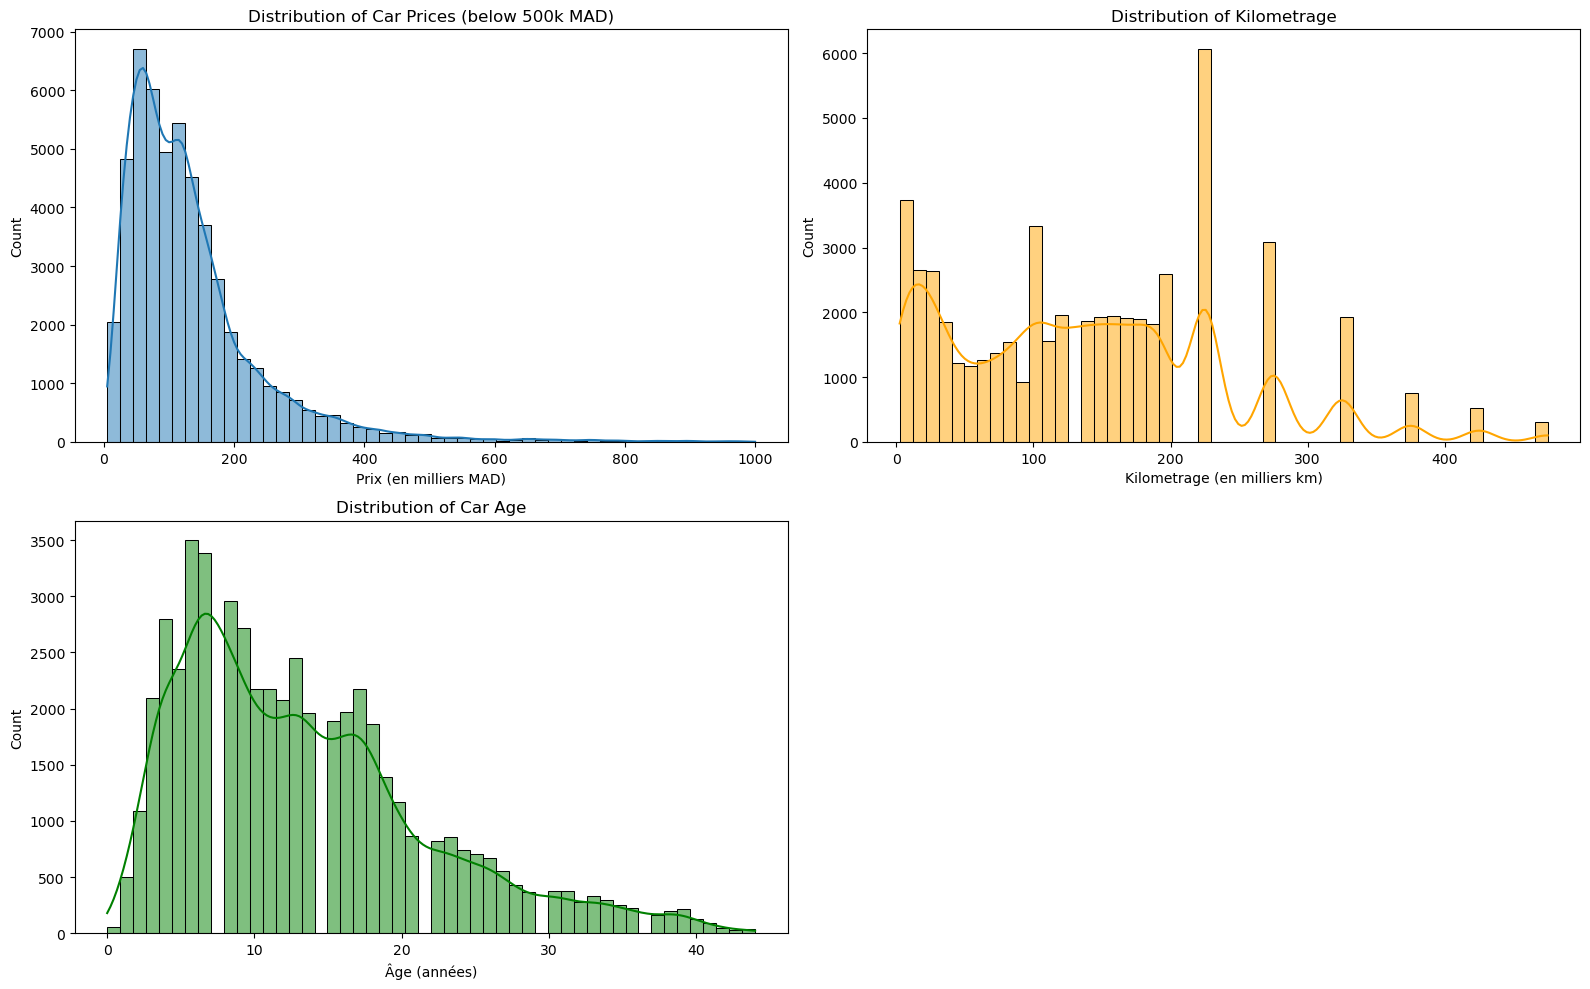

In [260]:
plt.figure(figsize=(16, 10))

# -----------------------------
# Distribution of Car Prices
# -----------------------------
plt.subplot(2, 2, 1)
sns.histplot(df_eda[df_eda['Prix (en milliers MAD)'] < 1000]['Prix (en milliers MAD)'], bins=50, kde=True)
plt.title('Distribution of Car Prices (below 500k MAD)')
plt.xlabel('Prix (en milliers MAD)')

# -----------------------------
# Distribution of Kilometrage
# -----------------------------
plt.subplot(2, 2, 2)
sns.histplot(df_eda['Kilometrage (en milliers km)'], bins=50, kde=True, color='orange')
plt.title('Distribution of Kilometrage')
plt.xlabel('Kilometrage (en milliers km)')

# -----------------------------
# Âge des voitures
# -----------------------------
plt.subplot(2, 2, 3)
sns.histplot(df_eda['Age'], bins=50, kde=True, color='green')
plt.title('Distribution of Car Age')
plt.xlabel('Âge (années)')

plt.tight_layout()
plt.show()


## 🔄 10. Data Transformation and Feature Engineering

Dans cette étape, nous appliquons plusieurs transformations sur les données pour améliorer l'analyse et mieux préparer les variables pour la modélisation :

1. **Transformation logarithmique des prix** : Nous appliquons la fonction `log1p` (logarithme de \(1 + x\)) à la variable des prix pour éviter les problèmes de valeurs nulles lors de l’application du logarithme. Cela permet de mieux traiter les distributions fortement asymétriques, comme c’est souvent le cas avec les prix.

2. **Ajout de bruit (jitter) au kilométrage** : Pour rendre la distribution du kilométrage plus fluide et moins dense, nous ajoutons un léger bruit (±5 milliers de km) aux valeurs de kilométrage. Cela permet de mieux visualiser les points et d'éviter que certaines valeurs trop proches les unes des autres ne perturbent les graphiques.

3. **Limitation de l'âge des voitures** : Nous limitons l’âge des voitures à un maximum de 50 ans. Toute voiture plus ancienne est regroupée sous la catégorie "50 ans et plus" pour éviter des outliers extrêmes dans l'analyse.

Ces transformations facilitent l'analyse et la modélisation en réduisant l'impact des valeurs extrêmes et en améliorant la distribution des variables.


In [261]:
# Apply log1p (log(1 + x)) to avoid log(0)
df_eda['log_price (en milliers MAD)'] = np.log1p(df_eda['Prix (en milliers MAD)'])
# df_eda.drop(columns=['Prix (en milliers MAD)'], inplace=True)

# Add jitter: ±5 (in thousands of km)
df_eda['Kilometrage lisse (en milliers km)'] = df_eda['Kilometrage (en milliers km)'] + np.random.uniform(-5, 5, size=len(df_eda))
df_eda.drop(columns=['Kilometrage (en milliers km)'], inplace=True)

# drop rows with negative values in 'Kilometrage lisse (en milliers km)'
df_eda = df_eda[df_eda['Kilometrage lisse (en milliers km)'] >= 0]

# Cap car age to 35 years (anything older is grouped as 35)
df_eda['Age (annees)'] = df_eda['Age'].clip(upper=50)
df_eda.drop(columns=['Age'], inplace=True)


## 📊 11. Visualisation des Transformations

Dans cette étape, nous visualisons les transformations appliquées précédemment aux données. Ces graphiques permettent de mieux comprendre l'impact des transformations sur les distributions des variables et d'examiner comment elles sont désormais distribuées.

1. **Prix des voitures (log-transformation)** : Nous affichons la distribution des prix des voitures après application de la transformation logarithmique. Cela permet de mieux gérer la skewness (asymétrie) des prix et d’obtenir une distribution plus régulière, ce qui est utile pour la modélisation.

2. **Kilométrage lissé** : Le graphique du kilométrage lissé montre la distribution après l'ajout de bruit (jitter) pour rendre les valeurs plus fluides. Cette transformation permet d'avoir une meilleure visibilité des données sur des graphiques en réduisant la densité excessive de points.

3. **Âge des voitures limité à 50 ans** : Cette visualisation montre la distribution des âges des voitures, où toutes les voitures de plus de 50 ans ont été regroupées sous cette limite. Cela permet d'éviter des outliers extrêmes et de mieux comprendre la répartition des véhicules en fonction de leur âge.

Ces transformations améliorent la gestion des données avant l'étape suivante de l'analyse ou de la modélisation.

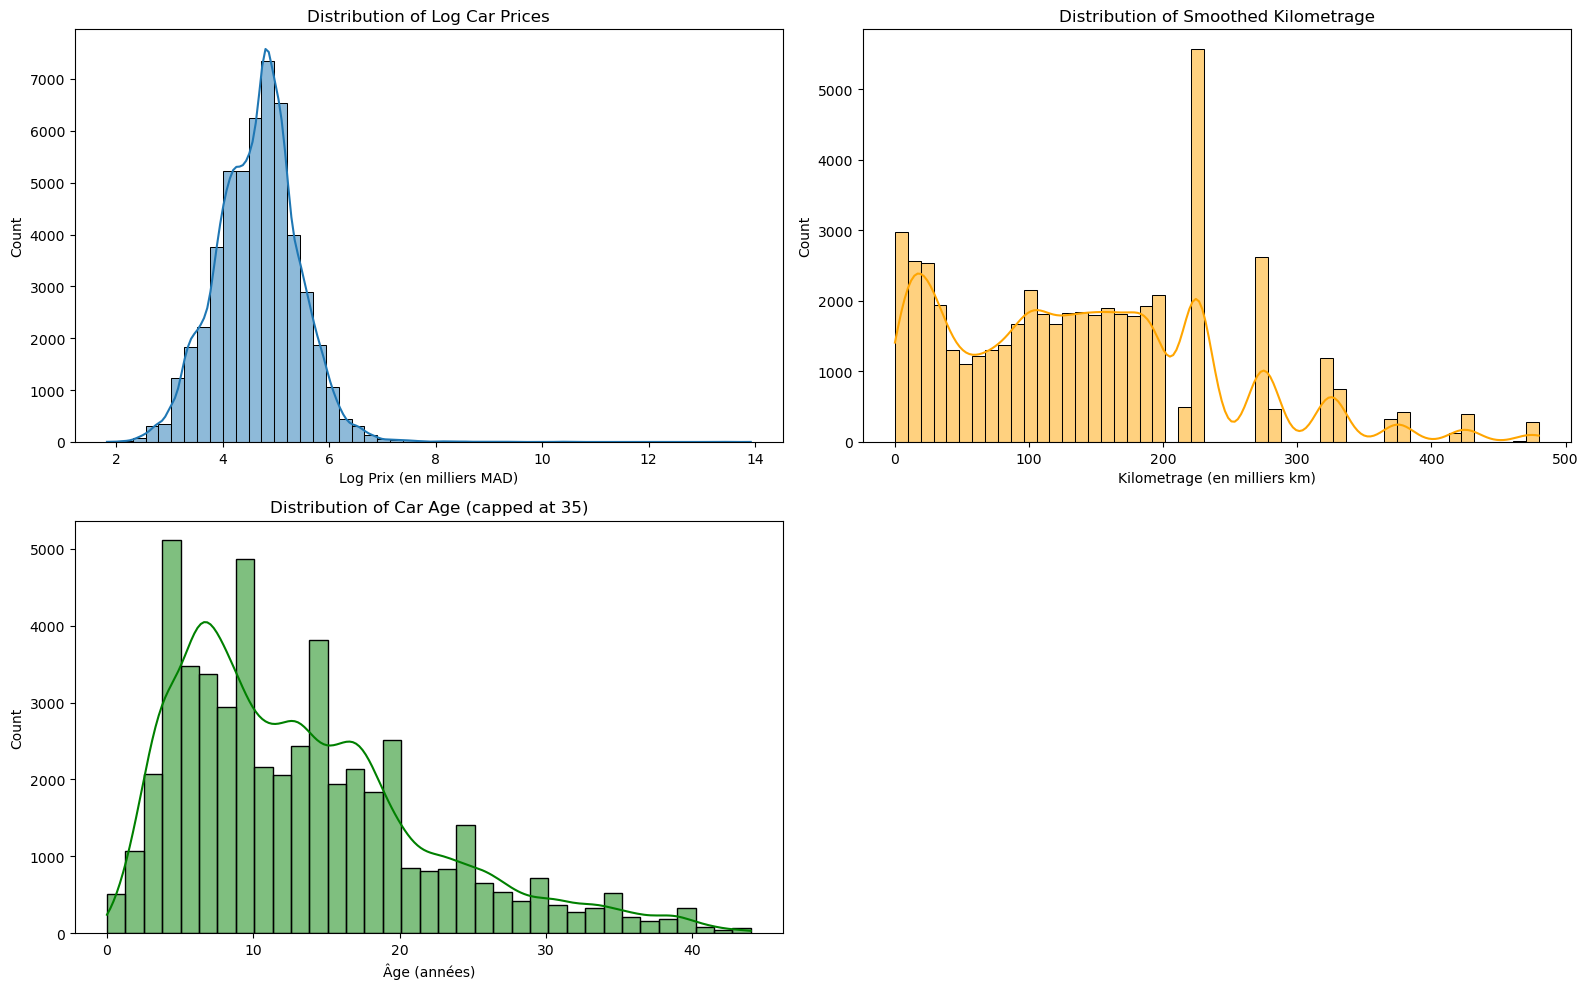

In [262]:
plt.figure(figsize=(16, 10))

# -----------------------------
# Log-transformed Price
# -----------------------------
plt.subplot(2, 2, 1)
sns.histplot(df_eda['log_price (en milliers MAD)'].dropna(), bins=50, kde=True)
plt.title('Distribution of Log Car Prices')
plt.xlabel('Log Prix (en milliers MAD)')

# -----------------------------
# Smoothed Kilometrage
# -----------------------------
plt.subplot(2, 2, 2)
sns.histplot(df_eda['Kilometrage lisse (en milliers km)'].dropna(), bins=50, kde=True, color='orange')
plt.title('Distribution of Smoothed Kilometrage')
plt.xlabel('Kilometrage (en milliers km)')

# -----------------------------
# Capped Age
# -----------------------------
plt.subplot(2, 2, 3)
sns.histplot(df_eda['Age (annees)'].dropna(), bins=35, kde=True, color='green')
plt.title('Distribution of Car Age (capped at 35)')
plt.xlabel('Âge (années)')

plt.tight_layout()
plt.show()

## 📊 12. Analyse des Fréquences des Variables Catégorielles

Dans cette étape, nous examinons la fréquence des voitures en fonction de différentes variables catégorielles du jeu de données. Ces visualisations permettent d'obtenir un aperçu des distributions des voitures selon plusieurs critères importants.

1. **Type de carburant** : Ce graphique montre la répartition des voitures en fonction du type de carburant. Cela nous aide à comprendre la popularité relative des différents types de carburant parmi les voitures du jeu de données.

2. **Boîte de vitesses** : Nous visualisons ici la fréquence des voitures selon leur type de boîte de vitesses, permettant de voir quelle boîte est la plus courante dans le dataset.

3. **Origine des voitures** : Cette visualisation montre la fréquence des voitures en fonction de leur origine. Cela peut donner un aperçu de la provenance des véhicules, ce qui est souvent un critère important dans l'achat de voitures d'occasion.

4. **État des voitures** : Le graphique montre la répartition des voitures selon leur état. Cela peut être utile pour observer la condition générale des véhicules et leur impact potentiel sur le prix.

5. **Nombre de portes** : Cette dernière visualisation montre la répartition des voitures en fonction du nombre de portes. Cela permet de voir si certaines configurations sont plus courantes que d'autres.

Ces visualisations sont importantes pour comprendre les tendances et la distribution des catégories dans le jeu de données, ce qui peut influencer les analyses ultérieures et les choix de modélisation.


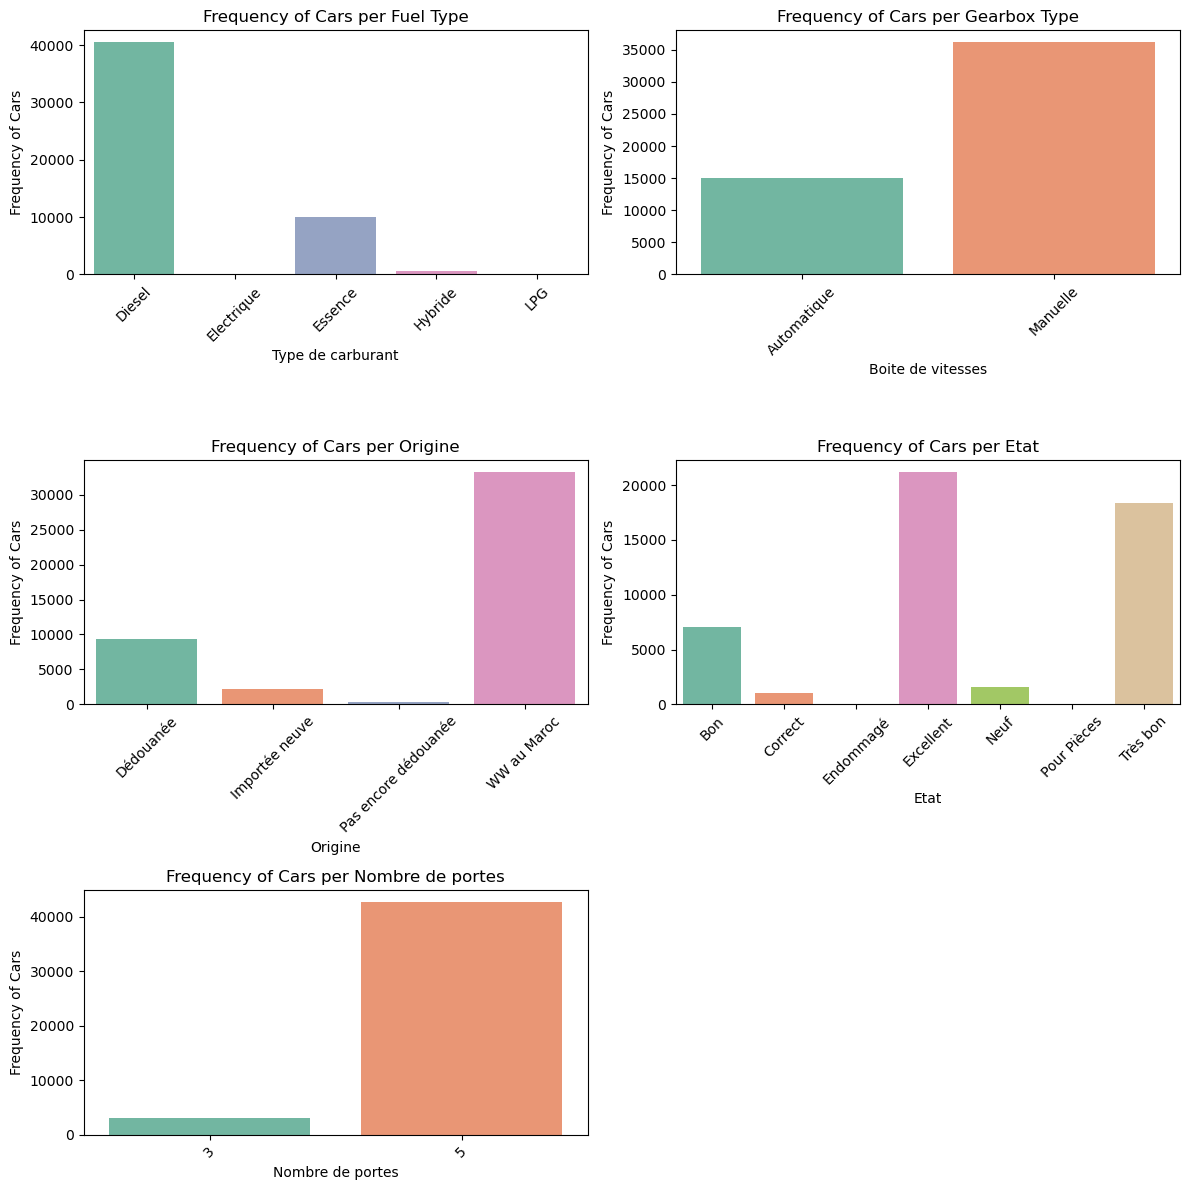

In [263]:
plt.figure(figsize=(12, 12))
# -----------------------------
# Count the number of cars per Fuel Type
# -----------------------------
fuel_counts = df_eda['Type de carburant'].value_counts().reset_index()
fuel_counts.columns = ['Type de carburant', 'Frequency']

plt.subplot(3, 2, 1)
sns.barplot(x='Type de carburant', y='Frequency', data=fuel_counts, palette="Set2", hue='Type de carburant',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Type de carburant')
plt.ylabel('Frequency of Cars')
plt.title('Frequency of Cars per Fuel Type')

# -----------------------------
# Count the number of cars per Boite de vitesses
# -----------------------------
gearbox_counts = df_eda['Boite de vitesses'].value_counts().reset_index()
gearbox_counts.columns = ['Boite de vitesses', 'Frequency']

plt.subplot(3, 2, 2)
sns.barplot(x='Boite de vitesses', y='Frequency', data=gearbox_counts, palette="Set2", hue='Boite de vitesses', legend=False)
plt.xticks(rotation=45)
plt.xlabel('Boite de vitesses')
plt.ylabel('Frequency of Cars')
plt.title('Frequency of Cars per Gearbox Type')

# -----------------------------
# Count the number of cars per Origine
# -----------------------------
Origine_counts = df_eda['Origine'].value_counts().reset_index()
Origine_counts.columns = ['Origine', 'Frequency']

plt.subplot(3, 2, 3)
sns.barplot(x='Origine', y='Frequency', data=Origine_counts, palette="Set2", hue='Origine', legend=False)
plt.xticks(rotation=45)
plt.xlabel('Origine')
plt.ylabel('Frequency of Cars')
plt.title('Frequency of Cars per Origine')

# -----------------------------
# Count the number of cars per Etat
# -----------------------------
Etat_counts = df_eda['Etat'].value_counts().reset_index()
Etat_counts.columns = ['Etat', 'Frequency']

plt.subplot(3, 2, 4)
sns.barplot(x='Etat', y='Frequency', data=Etat_counts, palette="Set2", hue='Etat', legend=False)
plt.xticks(rotation=45)
plt.xlabel('Etat')
plt.ylabel('Frequency of Cars')
plt.title('Frequency of Cars per Etat')

# -----------------------------
# Count the number of cars per Etat
# -----------------------------
portes_counts = df_eda['Nombre de portes'].value_counts().reset_index()
portes_counts.columns = ['Nombre de portes', 'Frequency']

plt.subplot(3, 2, 5)
sns.barplot(x='Nombre de portes', y='Frequency', data=portes_counts, palette="Set2", hue='Nombre de portes', legend=False)
plt.xticks(rotation=45)
plt.xlabel('Nombre de portes')
plt.ylabel('Frequency of Cars')
plt.title('Frequency of Cars per Nombre de portes')

# -----------------------------
plt.tight_layout()
plt.show()

## 📊 13. Analyse Bivariée du Prix Logarithmique par Variables Catégorielles

Cette étape vise à explorer la relation entre le prix logarithmique des voitures et plusieurs variables catégorielles importantes. En utilisant une transformation logarithmique du prix, nous visons à obtenir une meilleure distribution des prix et à mieux comprendre les relations entre ces variables.

1. **Type de carburant** : Ce graphique compare le prix log-transformed des voitures en fonction de leur type de carburant. Cela permet d'identifier si certains types de carburant sont associés à des prix plus élevés ou plus bas.

2. **Boîte de vitesses** : Ici, nous analysons la relation entre le type de boîte de vitesses et le prix des voitures. Cette analyse peut montrer si certains types de transmission sont associés à des prix plus élevés.

3. **Origine des voitures** : Le graphique montre comment l'origine des voitures influence leur prix logarithmique. Cela peut révéler si les voitures provenant de certaines origines sont généralement plus chères.

4. **État des voitures** : Cette visualisation explore la corrélation entre l'état des voitures et leur prix. Les voitures en meilleur état sont-elles généralement plus chères que celles en mauvais état?

5. **Nombre de portes** : Enfin, ce graphique examine comment le nombre de portes des voitures est lié au prix, ce qui peut être utile pour identifier les préférences des acheteurs.


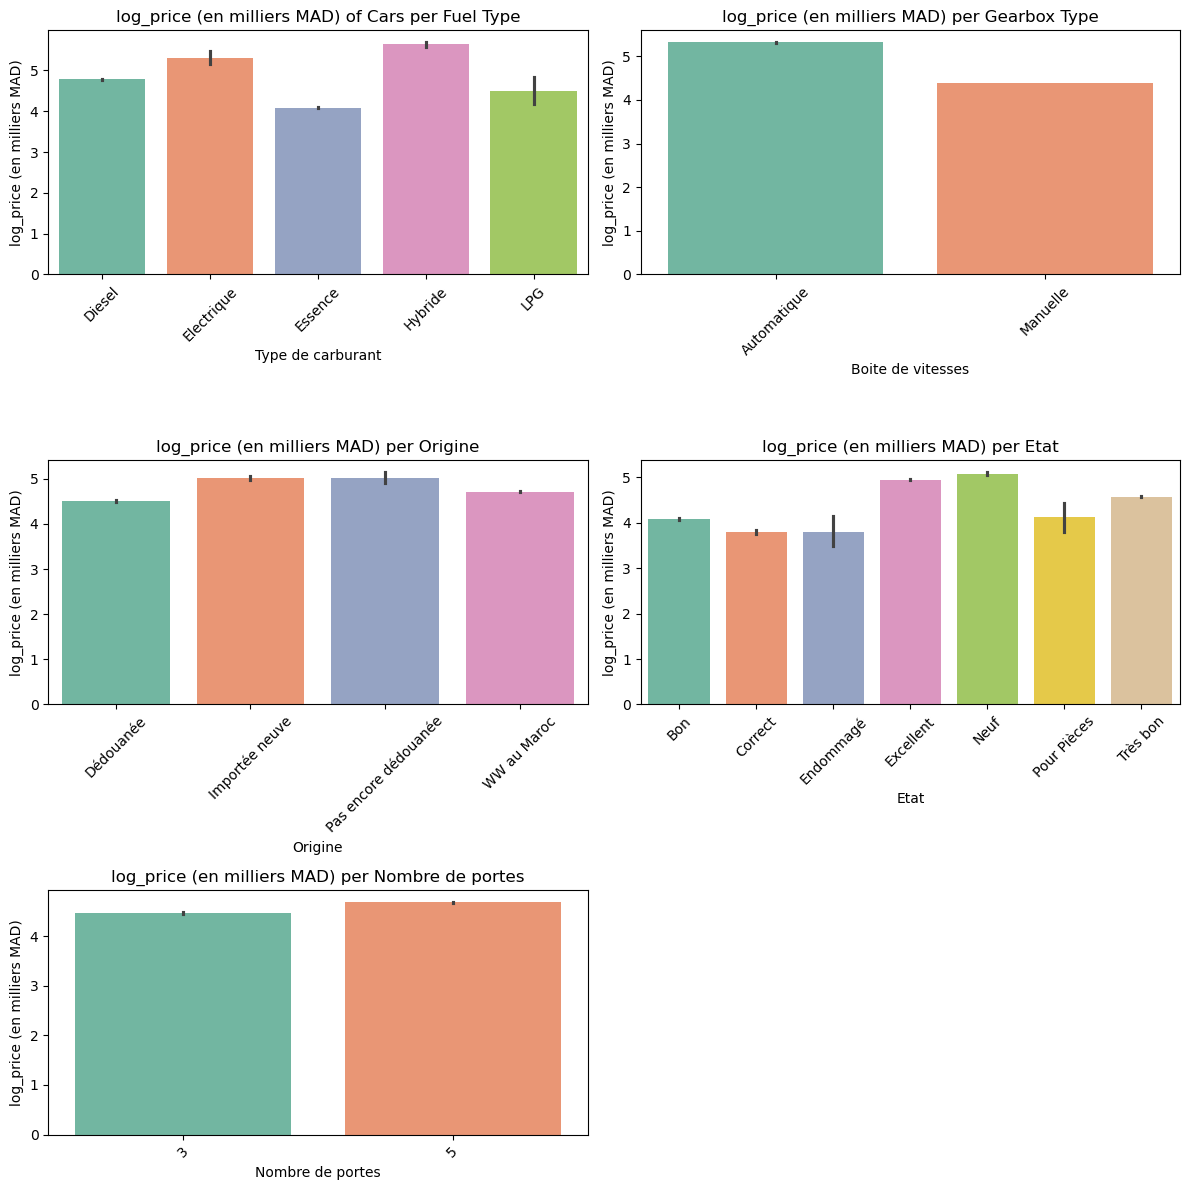

In [264]:
plt.figure(figsize=(12, 12))
# -----------------------------
# Count the number of cars per Fuel Type
# -----------------------------
plt.subplot(3, 2, 1)
sns.barplot(x='Type de carburant', y='log_price (en milliers MAD)', data=df_eda, palette="Set2", hue='Type de carburant')
plt.xticks(rotation=45)
plt.xlabel('Type de carburant')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) of Cars per Fuel Type')

# -----------------------------
# Count the number of cars per Boite de vitesses
# -----------------------------
plt.subplot(3, 2, 2)
sns.barplot(x='Boite de vitesses', y='log_price (en milliers MAD)', data=df_eda, palette="Set2", hue='Boite de vitesses',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Boite de vitesses')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) per Gearbox Type')

# -----------------------------
# Count the number of cars per Origine
# -----------------------------
plt.subplot(3, 2, 3)
sns.barplot(x='Origine', y='log_price (en milliers MAD)', data=df_eda, palette="Set2", hue='Origine',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Origine')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) per Origine')

# -----------------------------
# Count the number of cars per Etat
# -----------------------------
plt.subplot(3, 2, 4)
sns.barplot(x='Etat', y='log_price (en milliers MAD)', data=df_eda, palette="Set2", hue='Etat',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Etat')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) per Etat')

# -----------------------------
# Count the number of cars per Etat
# -----------------------------
plt.subplot(3, 2, 5)
sns.barplot(x='Nombre de portes', y='log_price (en milliers MAD)', data=df_eda, palette='Set2', hue='Nombre de portes',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Nombre de portes')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) per Nombre de portes')

# -----------------------------
plt.tight_layout()
plt.show()

## 📊 14. Analyse Bivariée du Prix Logarithmique par Variables Catégorielles avec Boxplots

Cette étape explore la relation entre le **prix logarithmique** des voitures et plusieurs variables catégorielles en utilisant des boxplots pour visualiser la distribution des prix, les médianes, et les valeurs aberrantes dans chaque catégorie.

1. **Type de carburant** : Ce boxplot montre comment le **prix logarithmique** des voitures varie en fonction de leur **type de carburant**. Cette analyse permet d'observer si certains types de carburant (essence, diesel, etc.) sont associés à des prix plus élevés ou plus bas.

2. **Boîte de vitesses** : Ce graphique explore la relation entre le **type de boîte de vitesses** (manuelle vs automatique) et le **prix logarithmique** des voitures. Cela permet d'identifier si les voitures avec certaines transmissions sont généralement plus chères.

3. **Origine des voitures** : Le boxplot montre comment l'**origine** des voitures influence leur **prix logarithmique**. Cette analyse peut révéler si les voitures d'origine nationale ou importée ont tendance à avoir des prix différents.

4. **État des voitures** : Cette visualisation montre comment l'**état** des voitures (neuve, bon état, etc.) affecte leur **prix logarithmique**. Les voitures en meilleur état ont-elles des prix significativement plus élevés que celles en mauvais état?

5. **Nombre de portes** : Enfin, ce boxplot examine comment le **nombre de portes** des voitures est lié au **prix logarithmique**. Cela peut fournir des insights sur l'impact du nombre de portes sur le prix des véhicules.


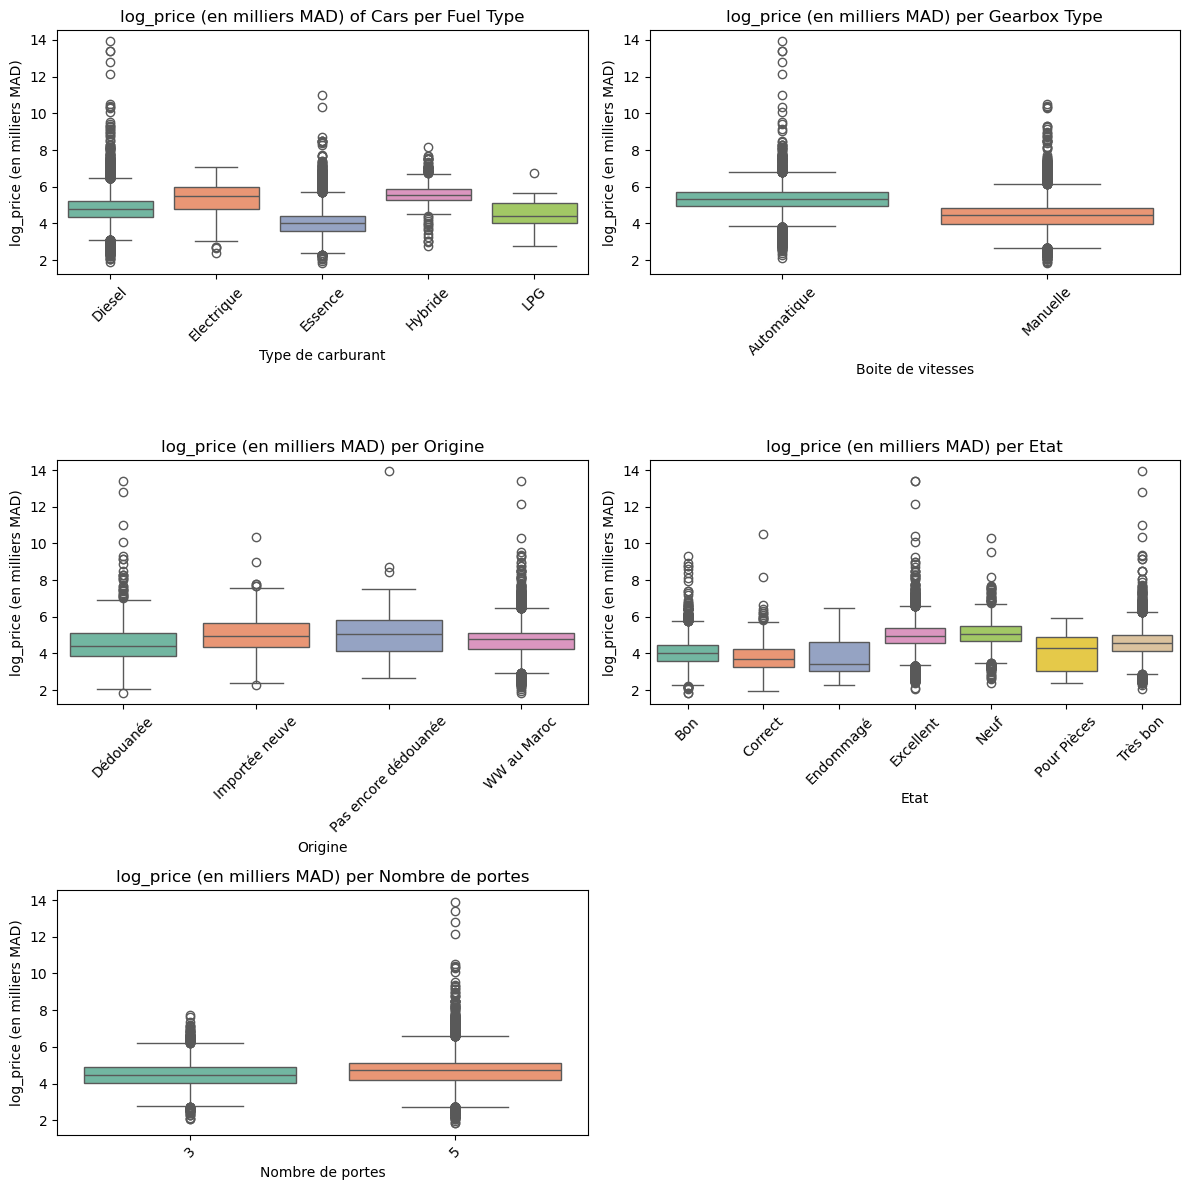

In [265]:
plt.figure(figsize=(12, 12))
# -----------------------------
# Boxplot Fuel Type
# -----------------------------
plt.subplot(3, 2, 1)
sns.boxplot(x='Type de carburant', y='log_price (en milliers MAD)', data=df_eda, palette="Set2", hue='Type de carburant')
plt.xticks(rotation=45)
plt.xlabel('Type de carburant')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) of Cars per Fuel Type')

# -----------------------------
# Boxplot Boite de vitesses
# -----------------------------
plt.subplot(3, 2, 2)
sns.boxplot(x='Boite de vitesses', y='log_price (en milliers MAD)', data=df_eda, palette="Set2", hue='Boite de vitesses',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Boite de vitesses')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) per Gearbox Type')

# -----------------------------
# Boxplot Origine
# -----------------------------
plt.subplot(3, 2, 3)
sns.boxplot(x='Origine', y='log_price (en milliers MAD)', data=df_eda, palette="Set2", hue='Origine',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Origine')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) per Origine')

# -----------------------------
# Boxplot Etat
# -----------------------------
plt.subplot(3, 2, 4)
sns.boxplot(x='Etat', y='log_price (en milliers MAD)', data=df_eda, palette="Set2", hue='Etat',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Etat')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) per Etat')

# -----------------------------
# Boxplot Nombre de portes
# -----------------------------
plt.subplot(3, 2, 5)
sns.boxplot(x='Nombre de portes', y='log_price (en milliers MAD)', data=df_eda, palette='Set2', hue='Nombre de portes',legend=False)
plt.xticks(rotation=45)
plt.xlabel('Nombre de portes')
plt.ylabel('log_price (en milliers MAD)')
plt.title('log_price (en milliers MAD) per Nombre de portes')

# -----------------------------
plt.tight_layout()
plt.show()

## 📊 15. Analyse des Outliers pour le Prix, l'Âge et le Kilométrage

Dans cette section, nous analysons les **outliers** pour trois variables importantes du dataset : le **prix**, l'**âge** et le **kilométrage** des voitures. Les boxplots sont utilisés pour identifier visuellement les points de données qui s'écartent fortement de la distribution normale et qui peuvent nécessiter une attention particulière.

1. **Outliers dans le Prix** : Le premier boxplot montre les **outliers** pour le **prix** logarithmique des voitures. Ces outliers peuvent indiquer des voitures avec des prix très élevés ou très bas qui nécessitent une analyse plus approfondie.

2. **Outliers dans l'Âge** : Le second graphique explore les **outliers** dans l'**âge** des voitures. Les voitures très anciennes ou très récentes peuvent être considérées comme des valeurs extrêmes, ce qui peut affecter les analyses futures.

3. **Outliers dans le Kilométrage** : Le dernier boxplot examine les **outliers** dans le **kilométrage** des voitures. Un kilométrage anormalement bas ou élevé pourrait signaler des erreurs de saisie ou des véhicules inhabituels.


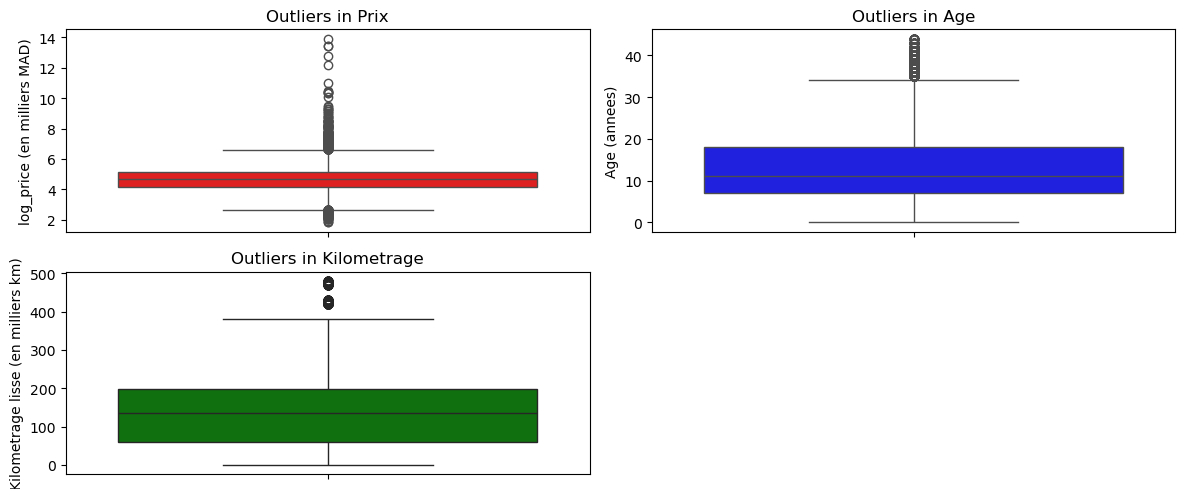

In [266]:
plt.figure(figsize=(12, 5))

plt.subplot(2, 2, 1)
sns.boxplot(y=df_eda['log_price (en milliers MAD)'],color='red')
plt.title('Outliers in Prix')

plt.subplot(2, 2, 2)
sns.boxplot(y=df_eda['Age (annees)'],color='blue')
plt.title('Outliers in Age')

plt.subplot(2, 2, 3)
sns.boxplot(y=df_eda['Kilometrage lisse (en milliers km)'],color='green')
plt.title('Outliers in Kilometrage')

plt.tight_layout()
plt.show()

## 📊 16. Traitement des Outliers avec la Méthode de l'IQR (Interquartile Range)

Dans cette section, nous appliquons la méthode de l'IQR pour supprimer les **outliers** dans les colonnes clés de notre dataset, à savoir **Prix**, **Kilométrage** et **Âge** des voitures.

1. **Méthode de l'IQR** : Nous calculons l'IQR (intervalle interquartile) pour chaque colonne, en déterminant les valeurs inférieures et supérieures à l'aide de la formule :
   - **Plage inférieure** = Q1 - 1.5 * IQR
   - **Plage supérieure** = Q3 + 1.5 * IQR
   Ensuite, nous filtrons les données pour conserver uniquement les observations dans ces plages.

2. **Filtrage des Prix Inférieurs à 20 000 MAD** : En plus du traitement des outliers, nous filtrons également les voitures dont le **prix** est inférieur à 20 000 MAD, car ces prix sont jugés non représentatifs de l'échantillon.

3. **Boxplots des Variables Clés** : Après le nettoyage des outliers, nous générons des **boxplots** pour visualiser les outliers restants dans les variables **Prix**, **Âge** et **Kilométrage**.
   - Le premier graphique montre les outliers pour le **prix**.
   - Le deuxième montre les outliers pour l'**âge** des voitures.
   - Le troisième visualise les outliers pour le **kilométrage**.

Ces graphiques permettent de vérifier si le filtrage a été efficace et de détecter toute autre anomalie dans les données.


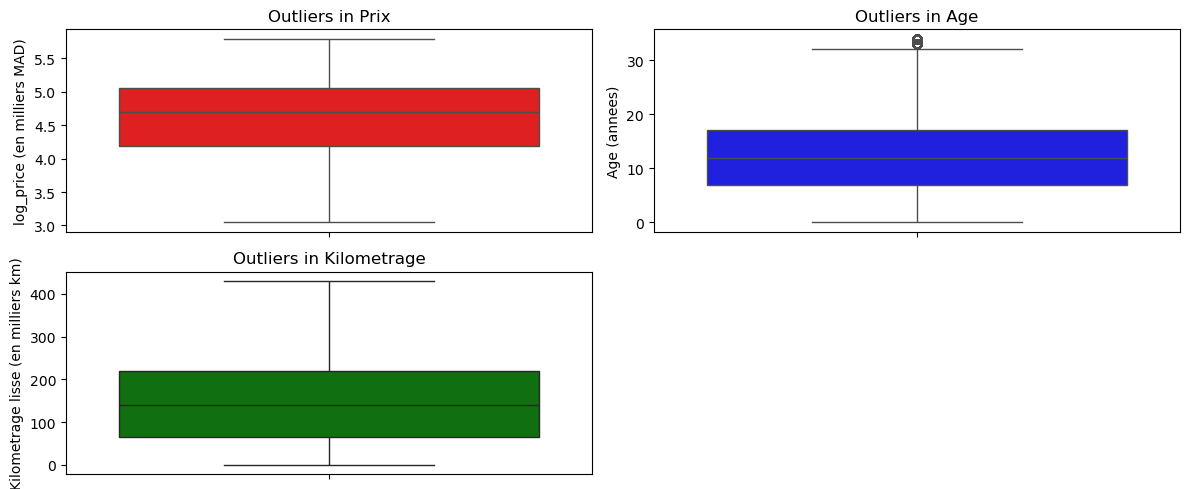

In [267]:
def remove_iqr_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Apply to key columns
for col in ['Prix (en milliers MAD)', 'Kilometrage lisse (en milliers km)', 'Age (annees)']:
    df_eda = remove_iqr_outliers(df_eda, col)

# Filter out prices less than 15,000 MAD
df_eda = df_eda[df_eda['Prix (en milliers MAD)'] >= 20]


plt.figure(figsize=(12, 5))

plt.subplot(2, 2, 1)
sns.boxplot(y=df_eda['log_price (en milliers MAD)'],color='red')
plt.title('Outliers in Prix')

plt.subplot(2, 2, 2)
sns.boxplot(y=df_eda['Age (annees)'],color='blue')
plt.title('Outliers in Age')

plt.subplot(2, 2, 3)
sns.boxplot(y=df_eda['Kilometrage lisse (en milliers km)'],color='green')
plt.title('Outliers in Kilometrage')

plt.tight_layout()
plt.show()

## 📊 17. Imputation des Valeurs Manquantes

Dans cette étape, nous traitons les **valeurs manquantes** dans plusieurs colonnes de notre dataset en utilisant différentes méthodes d'imputation :

1. **Variables Catégorielles** : Pour les variables catégorielles telles que **Secteur**, **Ville**, **Boîte de vitesses**, **Origine** et **État**, nous remplaçons les valeurs manquantes par la **valeur la plus fréquente** (mode) de chaque colonne. Cette approche est couramment utilisée pour éviter de perdre des informations importantes tout en maintenant une distribution fidèle des données.

2. **Nombre de portes** : Pour la variable **Nombre de portes**, nous appliquons également l'imputation par la **valeur la plus fréquente**. Si vous préférez, vous pourriez choisir d'ajouter une classe "Inconnue" pour représenter ces valeurs manquantes, mais ici, nous optons pour la valeur mode.

3. **Première main** : Pour la variable **Première main**, nous supposons que les valeurs manquantes correspondent à des voitures qui ne sont pas de première main. Nous remplaçons donc les valeurs manquantes par **"Non"** (ou `False` si la colonne est booléenne).

4. **Âge** : Enfin, pour la variable **Âge (années)**, nous choisissons de remplir les valeurs manquantes par la **médiane**, une approche robuste face aux outliers, afin de ne pas introduire de biais.

Ces imputations garantissent que nous n'avons pas de valeurs manquantes dans les variables clés, permettant ainsi une analyse et un modèle plus cohérents.


In [268]:
# 1. Fill categorical variables with most frequent value (mode)
for col in ['Boite de vitesses', 'Origine', 'Etat']:
    df_eda[col] = df_eda[col].fillna(df_eda[col].mode()[0])

# 2. Fill Nombre de portes with mode (or "Unknown" if you prefer a separate class)
df_eda['Nombre de portes'] = df_eda['Nombre de portes'].fillna(df_eda['Nombre de portes'].mode()[0])

# 3. Premiere main: fill with "Non" (assuming missing = not first-hand)
df_eda['Premiere main'] = df_eda['Premiere main'].fillna(False)

# 4. Age: fill with median (robust against outliers)
df_eda['Age (annees)'] = df_eda['Age (annees)'].fillna(df_eda['Age (annees)'].median())

## 📊 18. Analyse du Prix Logarithmique (log_price) par Variables

Dans cette étape, nous avons transformé le prix des voitures en utilisant une échelle logarithmique pour mieux analyser la distribution et les relations avec d'autres variables. Nous avons également supprimé la colonne originale **Prix (en milliers MAD)** après la transformation. Voici quelques graphiques clés pour explorer les relations entre **log_price (en milliers MAD)** et d'autres variables pertinentes :

1. **log_price vs Age (années)** : Ce graphique montre la relation entre l'âge des voitures et leur prix logarithmique. Il peut aider à identifier si les voitures plus anciennes ont tendance à être moins chères. Une ligne rouge indique la moyenne des **log_price** pour mieux visualiser les tendances générales.

2. **log_price vs Kilométrage (en milliers km)** : Ce graphique explore la relation entre le kilométrage des voitures et leur prix logarithmique. Cela permet de voir si un kilométrage plus élevé est associé à des prix plus bas, ce qui est souvent le cas pour les voitures avec plus de kilomètres au compteur.

3. **Matrice de Corrélation** : Cette carte thermique montre les corrélations entre les variables numériques du dataset. Les couleurs indiquent la force et la direction des corrélations. Les coefficients de corrélation sont annotés pour chaque paire de variables.

Ces visualisations aident à comprendre les principales tendances et relations dans le jeu de données, tout en facilitant l'identification de modèles qui peuvent être utilisés dans la modélisation prédictive.


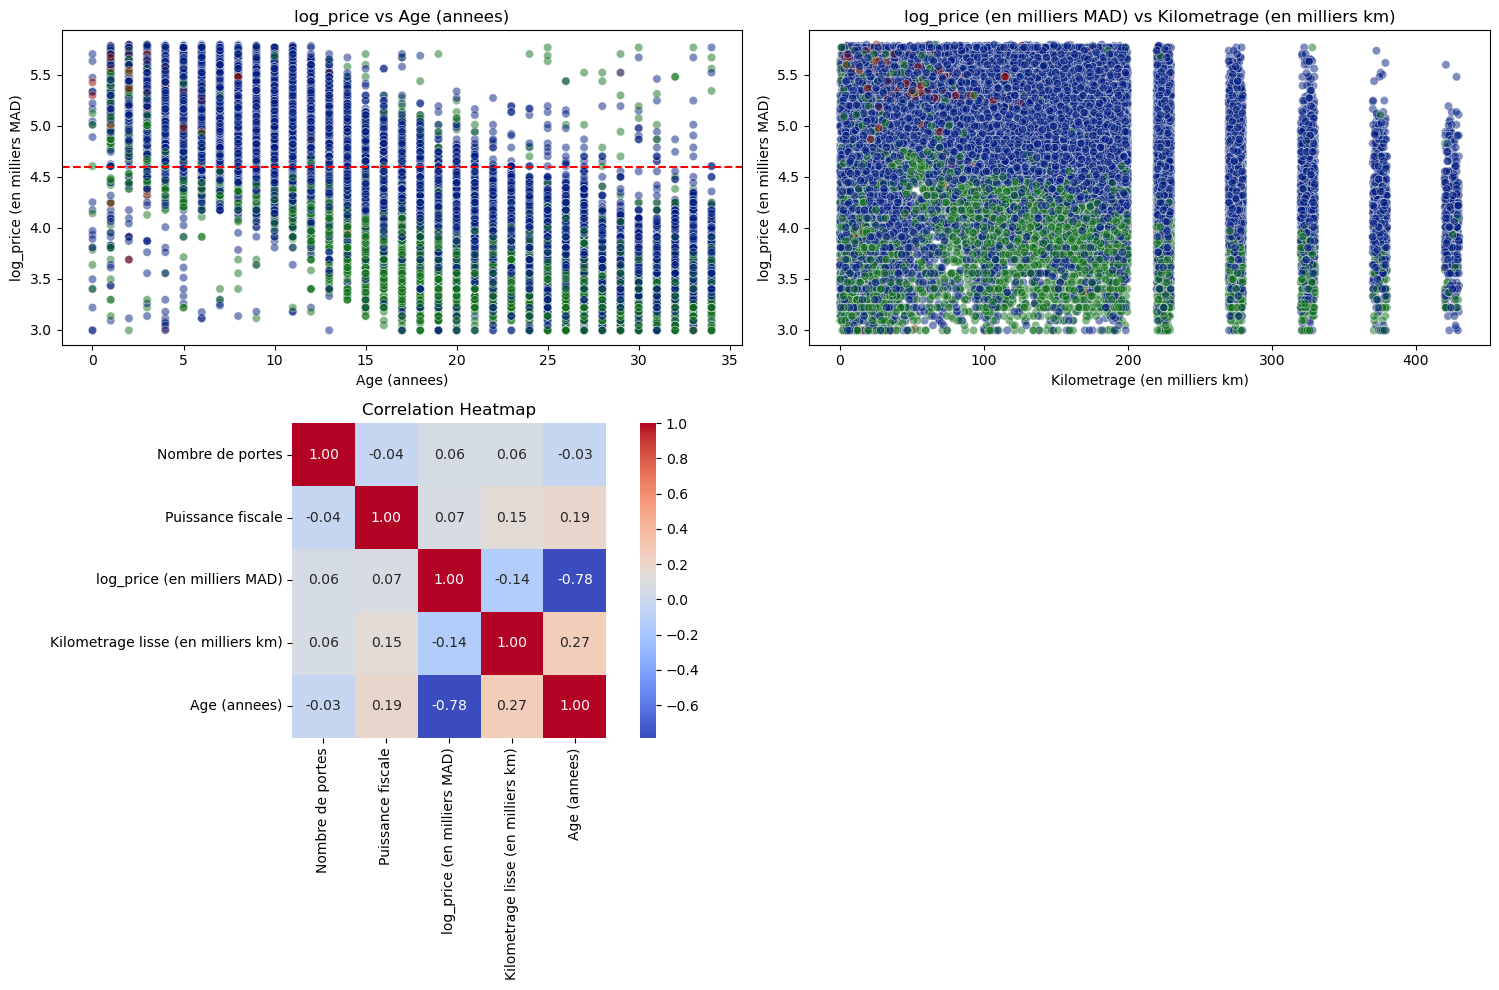

In [269]:
df_eda['log_price (en milliers MAD)'] = np.log(df_eda['Prix (en milliers MAD)'])
df_eda.drop(columns=['Prix (en milliers MAD)'], inplace=True)

# Set up plotting
plt.figure(figsize=(16, 10))

# -----------------------------
# PRICE VS YEAR
# -----------------------------
plt.subplot(2, 2, 1)
sns.scatterplot(data=df_eda, x='Age (annees)', y='log_price (en milliers MAD)', alpha=0.5, palette='dark', hue='Type de carburant', legend=False)
plt.axhline(y=df_eda['log_price (en milliers MAD)'].mean(), color='r', linestyle='--', label='Mean log_price')
plt.title("log_price vs Age (annees)")
plt.xlabel("Age (annees)")
plt.ylabel("log_price (en milliers MAD)")

# -----------------------------
# PRICE VS MILEAGE
# -----------------------------
plt.subplot(2, 2, 2)
sns.scatterplot(data=df_eda, x='Kilometrage lisse (en milliers km)', y='log_price (en milliers MAD)', alpha=0.5, palette='dark', hue='Type de carburant', legend=False)
plt.title("log_price (en milliers MAD) vs Kilometrage (en milliers km)")
plt.xlabel("Kilometrage (en milliers km)")
plt.ylabel("log_price (en milliers MAD)")

# -----------------------------
# CORRELATION HEATMAP
# -----------------------------
plt.subplot(2, 2, 3)
numeric_cols = df_eda.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [270]:
# Check for missing values
print(df_eda.isna().sum())
df_eda

Secteur                               0
Ville                                 0
Boite de vitesses                     0
Type de carburant                     0
Marque                                0
Modele                                0
Nombre de portes                      0
Origine                               0
Premiere main                         0
Puissance fiscale                     0
Etat                                  0
log_price (en milliers MAD)           0
Kilometrage lisse (en milliers km)    0
Age (annees)                          0
dtype: int64


,Secteur,Ville,Boite de vitesses,Type de carburant,Marque,Modele,Nombre de portes,Origine,Premiere main,Puissance fiscale,Etat,log_price (en milliers MAD),Kilometrage lisse (en milliers km),Age (annees)
2,route ain chkaf,fès,Automatique,Diesel,volkswagen,golf 7,5,WW au Maroc,False,7,Très bon,5.117994,5.694376,8
3,hay karima,salé,Manuelle,Essence,renault,megane,5,WW au Maroc,True,9,Très bon,3.828641,329.689244,17
6,anfa,casablanca,Automatique,Diesel,porsche,macan,5,WW au Maroc,False,12,Excellent,5.752573,221.320681,10
7,bir rami,kénitra,Manuelle,Diesel,renault,clio,5,WW au Maroc,True,6,Bon,4.700480,106.898035,6
9,centre ville,tanger,Automatique,Diesel,mercedes-benz,classe c,5,Importée neuve,False,7,Très bon,5.541264,155.5153,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74365,sala el jadida,salé,Manuelle,Essence,renault,megane,5,Dédouanée,True,9,Très bon,3.555348,276.04278,22
74366,hay hassani,casablanca,Automatique,Diesel,hyundai,i30,5,WW au Maroc,True,6,Très bon,4.962845,126.818745,9
74367,autre secteur,meknès,Manuelle,Diesel,mitsubishi,pick up,3,WW au Maroc,True,10,Très bon,4.499810,37.140346,14
74368,belvédère,casablanca,Manuelle,Diesel,dacia,dokker,3,WW au Maroc,False,6,Excellent,4.564348,94.177707,6


In [271]:
df_eda.to_csv("avito_data_EDA.csv", index=False)

df_eda.isna().sum()

Secteur                               0
Ville                                 0
Boite de vitesses                     0
Type de carburant                     0
Marque                                0
Modele                                0
Nombre de portes                      0
Origine                               0
Premiere main                         0
Puissance fiscale                     0
Etat                                  0
log_price (en milliers MAD)           0
Kilometrage lisse (en milliers km)    0
Age (annees)                          0
dtype: int64